# Orders & sales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

In [ ]:
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

In [ ]:
orders=pd.read_csv(DATA_DIR + "orders.csv", parse_dates=["order_date"])
order_items=pd.read_csv(DATA_DIR + "order_items.csv", low_memory=False)
products=pd.read_csv(DATA_DIR + "products.csv")
customers=pd.read_csv(DATA_DIR + "customers.csv", parse_dates=["signup_date"])
geography=pd.read_csv(DATA_DIR + "geography.csv")
sales=pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])

In [ ]:
oi=order_items.copy()
oi["revenue"]=oi["quantity"] * oi["unit_price"] - oi["discount_amount"]
oi["gross_rev"]=oi["quantity"] * oi["unit_price"]

In [ ]:
base = (oi
    .merge(orders[["order_id","order_date","customer_id","zip",
                   "order_status","device_type","order_source"]], on="order_id")
    .merge(geography[["zip","region"]], on="zip", how="left")
    .merge(customers[["customer_id","gender","age_group","acquisition_channel"]], on="customer_id", how="left")
    .merge(products[["product_id","category","cogs"]], on="product_id", how="left")
)

In [ ]:
base["year"]  = base["order_date"].dt.year
base["month"] = base["order_date"].dt.month
base["gm"]    = base["revenue"] - base["quantity"] * base["cogs"]

print(f"Rows: {len(base):,} | Orders: {base['order_id'].nunique():,} | Customers: {base['customer_id'].nunique():,}")

Rows: 714,669 | Orders: 646,945 | Customers: 90,246


# Overall KPIs

In [ ]:
total_rev  = base["revenue"].sum()
total_cogs = (base["quantity"] * base["cogs"]).sum()
total_gm   = base["gm"].sum()
n_orders   = base["order_id"].nunique()
n_cust     = base["customer_id"].nunique()
aov        = base.groupby("order_id")["revenue"].sum().mean()
arpu       = total_rev / n_cust
gm_pct     = total_gm / total_rev * 100

kpi = pd.DataFrame({
    "KPI":   ["Tong Revenue", "Tong COGS", "Gross Profit", "Gross Margin %",
               "So don hang", "So khach hang", "AOV", "ARPU"],
    "Value": [f"{total_rev/1e9:.2f}B VND", f"{total_cogs/1e9:.2f}B VND",
               f"{total_gm/1e9:.2f}B VND", f"{gm_pct:.2f}%",
               f"{n_orders:,}", f"{n_cust:,}",
               f"{aov:,.0f} VND", f"{arpu:,.0f} VND"]
})
print(kpi.to_string(index=False))

           KPI       Value
  Tong Revenue  15.68B VND
     Tong COGS  14.16B VND
  Gross Profit   1.52B VND
Gross Margin %       9.68%
   So don hang     646,945
 So khach hang      90,246
           AOV  24,238 VND
          ARPU 173,757 VND


## 2. Doanh thu theo nam - Revenue, Gross Profit, AOV trend

## 1. Tại sao doanh thu vào năm 2017 và đến năm 2019 nó lại lỗ đến 39% và điều gì đã làm cho doanh thu từ -39% giảm còn -7% vào năm 2020
## 2. Năm 2021 doanh thu lỗ còn -1% đến năm 2022 thì tại sao nó lại phục hồi nhẹ lên +13%? Lý do nằm ở sản phẩm nào mà khiến nó +13%
## 3. AOV của đơn hàng thì dao động vào năm 2012 23.1K nhưng điều gì đã khiến nó tăng trưởng lên trung bình 1 đơn hàng là 31K ( Mình có thể dựa vào đây để phát triển xem doanh thu nó đến từ sản phẩm nào để tiếp đến tăng trưởng doanh thu)

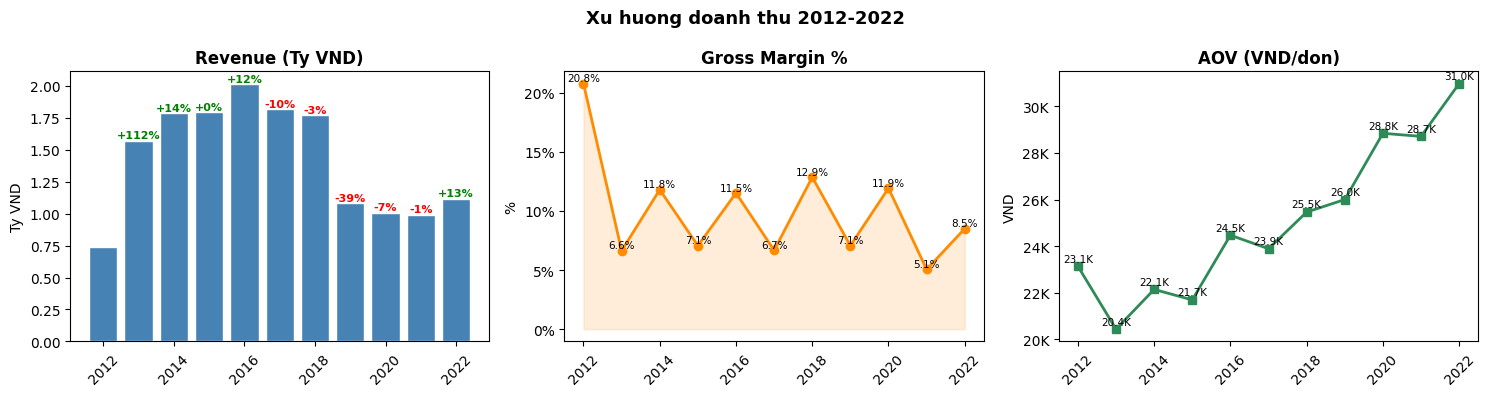

=== INSIGHT: AOV tang deu du revenue giam ===
AOV 2013: 20,432 VND | AOV 2022: 30,977 VND | Tang: 51.6%
=> Khach hang con lai la nhom trung thanh, chi tieu nhieu hon per order
=> Revenue giam khong phai vi san pham kem ma vi khong co khach moi


In [ ]:
yr = base.groupby("year").agg(
    revenue  = ("revenue",  "sum"),
    gm       = ("gm",       "sum"),
    n_orders = ("order_id", "nunique"),
    n_cust   = ("customer_id","nunique")
).reset_index()
yr["gm_pct"] = yr["gm"]      / yr["revenue"] * 100
yr["aov"]    = yr["revenue"]  / yr["n_orders"]
yr["arpu"]   = yr["revenue"]  / yr["n_cust"]
yr["rev_yoy"]= yr["revenue"].pct_change() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Xu huong doanh thu 2012-2022", fontsize=13, fontweight="bold")

axes[0].bar(yr["year"], yr["revenue"]/1e9, color="steelblue", edgecolor="white")
axes[0].set_title("Revenue (Ty VND)", fontweight="bold")
axes[0].set_ylabel("Ty VND")
for _, r in yr.iterrows():
    if not pd.isna(r["rev_yoy"]):
        clr = "green" if r["rev_yoy"] >= 0 else "red"
        axes[0].text(r["year"], r["revenue"]/1e9 + 0.02,
                     f"{r['rev_yoy']:+.0f}%", ha="center", fontsize=8, color=clr, fontweight="bold")

axes[1].plot(yr["year"], yr["gm_pct"], "o-", color="darkorange", linewidth=2, markersize=6)
axes[1].fill_between(yr["year"], yr["gm_pct"], alpha=0.15, color="darkorange")
axes[1].set_title("Gross Margin %", fontweight="bold")
axes[1].set_ylabel("%")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for _, r in yr.iterrows():
    axes[1].text(r["year"], r["gm_pct"] + 0.2, f"{r['gm_pct']:.1f}%", ha="center", fontsize=7.5)

axes[2].plot(yr["year"], yr["aov"], "s-", color="seagreen", linewidth=2, markersize=6)
axes[2].set_title("AOV (VND/don)", fontweight="bold")
axes[2].set_ylabel("VND")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
for _, r in yr.iterrows():
    axes[2].text(r["year"], r["aov"] + 200, f"{r['aov']/1000:.1f}K", ha="center", fontsize=7.5)

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# INSIGHT
print("=== INSIGHT: AOV tang deu du revenue giam ===")
aov_2013 = yr[yr["year"]==2013]["aov"].values[0]
aov_2022 = yr[yr["year"]==2022]["aov"].values[0]
print(f"AOV 2013: {aov_2013:,.0f} VND | AOV 2022: {aov_2022:,.0f} VND | Tang: {(aov_2022/aov_2013-1)*100:.1f}%")
print("=> Khach hang con lai la nhom trung thanh, chi tieu nhieu hon per order")
print("=> Revenue giam khong phai vi san pham kem ma vi khong co khach moi")

## Tính mùa vụ

## 1. Tại sao lại chọn từ năm 2018-2022 mà không phải là 2012-2022
## 2. Tại sao theo từng tháng thì chỉ có tháng 4 5 6 lại có doanh thu cao nhất?
## 3. Các tháng cuối như tháng 11 và tháng 12 lại có số lợi nhuận thấp hơn
## 4. Về heapmap thì so sánh giữa các năm thì ta thấy được năm 2018 thì doanh thu tăng mạnh và đến năm 2019 đến 2022 thì nó lại giảm đi nhể? Vấn đề gì đã làm cho nó giảm?


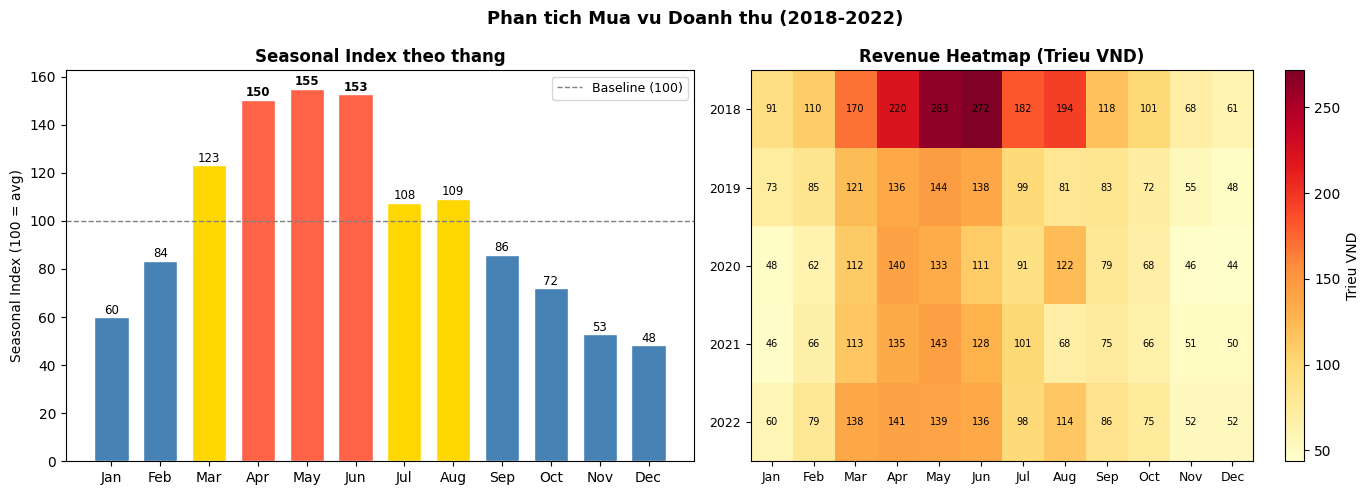

=== SEASONALITY FINDINGS ===
Peak months:
 month  seasonal_index
  May           154.9
  Jun           152.7
  Apr           150.3
Low months:
 month  seasonal_index
  Dec            48.3
  Nov            52.9
  Jan            59.9
Peak/Low ratio: 3.2x
=> Peak T4-T6 (mua he), Low T11-T12 - nguoc voi retail thuong (no Xmas spike)
=> Lien quan forecasting: spike T4-T6 la pattern quan trong nhat can model hoc
4 | 150, 5 | 155 , 6 | 153 MEAN 100 2012-2022


In [ ]:
sales["month"]=sales["Date"].dt.month
sales["year"]=sales["Date"].dt.year

monthly = (sales[sales["year"].between(2018, 2022)].groupby("month")["Revenue"].agg(["mean","std"]).reset_index())
monthly.columns= ["month","mean_rev","std_rev"]
annual_mean= monthly["mean_rev"].mean()
monthly["seasonal_index"] = (monthly["mean_rev"] / annual_mean * 100).round(1)
months_lbl= ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig,(ax1,ax2)= plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phan tich Mua vu Doanh thu (2018-2022)", fontsize=13, fontweight="bold")

colors_m= ["tomato" if v > 130 else ("gold" if v > 90 else "steelblue")
            for v in monthly["seasonal_index"]]
bars= ax1.bar(months_lbl, monthly["seasonal_index"], color=colors_m, edgecolor="white", width=0.7)
ax1.axhline(y=100, color="gray", linestyle="--", linewidth=1, label="Baseline (100)")
ax1.set_title("Seasonal Index theo thang", fontweight="bold")
ax1.set_ylabel("Seasonal Index (100 = avg)")
ax1.legend(fontsize=9)
for bar, val in zip(bars, monthly["seasonal_index"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1.5,
             f"{val:.0f}", ha="center", fontsize=8.5,
             fontweight="bold" if val > 130 else "normal")

pivot = sales[sales["year"].between(2018,2022)].pivot_table(
    index="year", columns="month", values="Revenue", aggfunc="sum") / 1e6
pivot.columns = months_lbl
im = ax2.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax2.set_xticks(range(12)); ax2.set_xticklabels(months_lbl, fontsize=9)
ax2.set_yticks(range(5)); ax2.set_yticklabels(pivot.index, fontsize=9)
ax2.set_title("Revenue Heatmap (Trieu VND)", fontweight="bold")
plt.colorbar(im, ax=ax2, label="Trieu VND")
for i in range(5):
    for j in range(12):
        ax2.text(j, i, f"{pivot.values[i,j]:.0f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

print("=== SEASONALITY FINDINGS ===")
peak = monthly.nlargest(3,"seasonal_index")[["month","seasonal_index"]].copy()
low  = monthly.nsmallest(3,"seasonal_index")[["month","seasonal_index"]].copy()
peak["month"] = peak["month"].map(dict(enumerate(months_lbl, 1)))
low["month"]  = low["month"].map(dict(enumerate(months_lbl, 1)))
print("Peak months:\n", peak.to_string(index=False))
print("Low months:\n",  low.to_string(index=False))
print(f"Peak/Low ratio: {monthly['seasonal_index'].max()/monthly['seasonal_index'].min():.1f}x")
print("=> Peak T4-T6 (mua he), Low T11-T12 - nguoc voi retail thuong (no Xmas spike)")
print("=> Lien quan forecasting: spike T4-T6 la pattern quan trong nhat can model hoc")
print("4 | 150, 5 | 155 , 6 | 153 MEAN 100 2012-2022")

## Phân tích theo Category

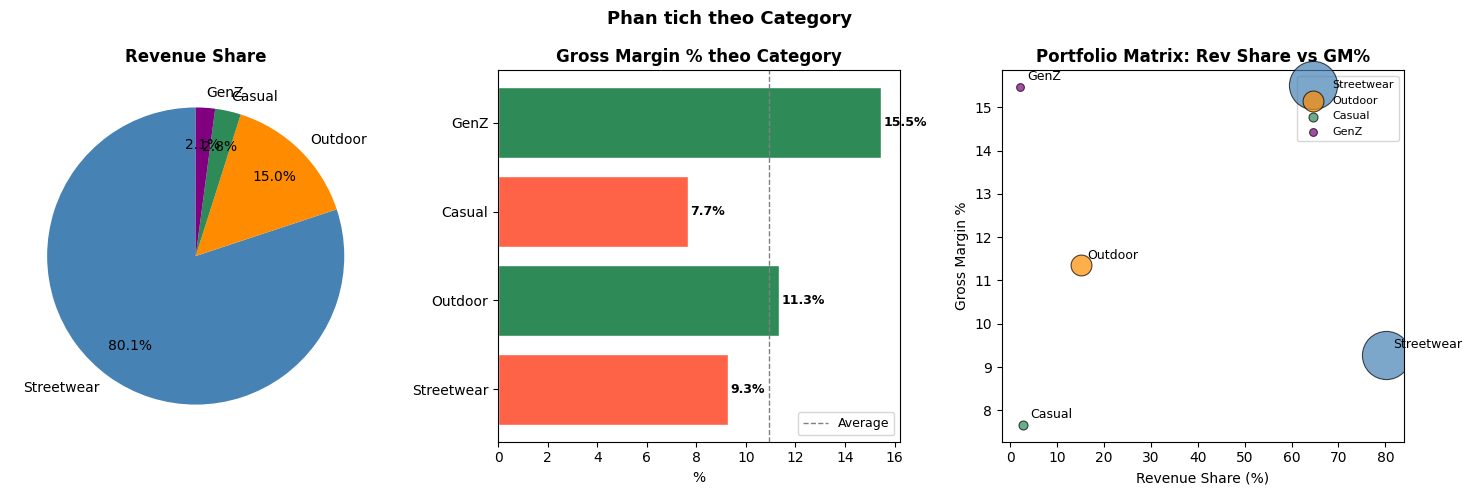

=== CATEGORY FULL TABLE ===
  category  rev_share    gm_pct          aov          arpu
Streetwear  80.087889  9.283033 32239.000827 162642.972210
   Outdoor  15.008076 11.346752 11740.333427  39806.444358
    Casual   2.807786  7.663389 18656.152278  25693.580401
      GenZ   2.096250 15.465410  8871.111773  14077.523582

=> GenZ: GM% cao nhat (15.5%) nhung rev share thap nhat (2.1%) - co hoi bi bo ngo
=> Streetwear: 80% revenue nhung GM% thap nhat (9.3%) - over-reliance, under-margin


In [ ]:
cat= base.groupby("category").agg(
    revenue= ("revenue","sum"),
    gm= ("gm","sum"),
    n_orders= ("order_id", "nunique"),
    n_cust= ("customer_id","nunique")
).reset_index()
cat["gm_pct"]= cat["gm"] / cat["revenue"] * 100
cat["aov"]= cat["revenue"] / cat["n_orders"]
cat["arpu"]= cat["revenue"] / cat["n_cust"]
cat["rev_share"]= cat["revenue"] / cat["revenue"].sum() * 100
cat = cat.sort_values("revenue", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Phan tich theo Category", fontsize=13, fontweight="bold")

colors_c = ["steelblue","darkorange","seagreen","purple"]
axes[0].pie(cat["rev_share"], labels=cat["category"],
            autopct="%1.1f%%", colors=colors_c, startangle=90, pctdistance=0.75)
axes[0].set_title("Revenue Share", fontweight="bold")

bars = axes[1].barh(cat["category"], cat["gm_pct"],
                    color=["tomato" if v < 10 else "seagreen" for v in cat["gm_pct"]],
                    edgecolor="white")
axes[1].axvline(x=cat["gm_pct"].mean(), color="gray", linestyle="--", linewidth=1, label="Average")
axes[1].set_title("Gross Margin % theo Category", fontweight="bold")
axes[1].set_xlabel("%")
axes[1].legend(fontsize=9)
for bar, v in zip(bars, cat["gm_pct"]):
    axes[1].text(v + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{v:.1f}%", va="center", fontsize=9, fontweight="bold")

for i, (_, r) in enumerate(cat.iterrows()):
    axes[2].scatter(r["rev_share"], r["gm_pct"], s=r["rev_share"]*15,
                    color=colors_c[i], alpha=0.7, edgecolors="black", linewidth=0.8, label=r["category"])
    axes[2].annotate(r["category"], (r["rev_share"], r["gm_pct"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[2].set_xlabel("Revenue Share (%)")
axes[2].set_ylabel("Gross Margin %")
axes[2].set_title("Portfolio Matrix: Rev Share vs GM%", fontweight="bold")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("=== CATEGORY FULL TABLE ===")
print(cat[["category","rev_share","gm_pct","aov","arpu"]].to_string(index=False))
print("\n=> GenZ: GM% cao nhat (15.5%) nhung rev share thap nhat (2.1%) - co hoi bi bo ngo")
print("=> Streetwear: 80% revenue nhung GM% thap nhat (9.3%) - over-reliance, under-margin")
# Streetwear 4 phan nho 
# doanh thu theo kênh
# 

## Region, Gender, Age Group

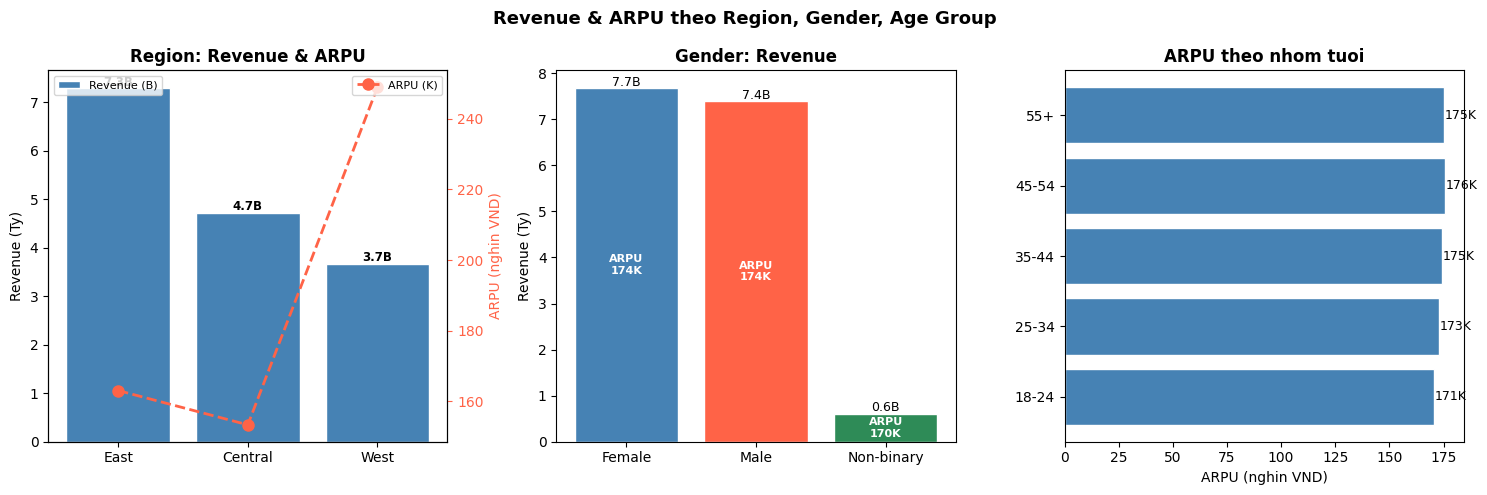

=== REGION INSIGHTS ===
 region      revenue          arpu          aov    gm_pct
   East 7.291151e+09 163036.399435 24748.315816  9.540995
Central 4.719491e+09 153309.877464 25553.444769  9.387896
   West 3.670227e+09 248980.881790 21893.243808 10.318422

=> West: ARPU cao nhat (248,981) nhung revenue thap nhat - premium market bi bo ngo
=> East: chiem 46% revenue, volume lon nhat

=== AGE GROUP ===
age_group          arpu          aov
    45-54 175616.811192 24322.768490
      55+ 175106.409990 24090.367839
    35-44 174531.844752 24219.817534
    25-34 172748.700375 24288.962803
    18-24 170837.505004 24168.585575
=> Chenh lech ARPU theo tuoi nho (~3%) - loyalty chu khong phai demographic drive revenue


In [ ]:
def agg_kpi(df, by):
    g = df.groupby(by).agg(
        revenue = ("revenue",  "sum"),
        gm = ("gm",       "sum"),
        n_orders = ("order_id", "nunique"),
        n_cust = ("customer_id","nunique")
    ).reset_index()
    g["gm_pct"] = g["gm"] / g["revenue"] * 100
    g["aov"] = g["revenue"] / g["n_orders"]
    g["arpu"] = g["revenue"] / g["n_cust"]
    g["rev_share"] = g["revenue"] / g["revenue"].sum() * 100
    return g.sort_values("revenue", ascending=False)

reg = agg_kpi(base, "region")
gen = agg_kpi(base, "gender")
age = agg_kpi(base, "age_group").sort_values("age_group")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Revenue & ARPU theo Region, Gender, Age Group", fontsize=13, fontweight="bold")

x = range(len(reg))
axes[0].bar(x, reg["revenue"]/1e9, color="steelblue", label="Revenue (B)", edgecolor="white")
ax0t = axes[0].twinx()
ax0t.plot(x, reg["arpu"]/1000, "o--", color="tomato", linewidth=2, markersize=8, label="ARPU (K)")
ax0t.set_ylabel("ARPU (nghin VND)", color="tomato"); ax0t.tick_params(colors="tomato")
axes[0].set_xticks(x); axes[0].set_xticklabels(reg["region"])
axes[0].set_title("Region: Revenue & ARPU", fontweight="bold")
axes[0].set_ylabel("Revenue (Ty)"); axes[0].legend(loc="upper left", fontsize=8)
ax0t.legend(loc="upper right", fontsize=8)
for i, (_, r) in enumerate(reg.iterrows()):
    axes[0].text(i, r["revenue"]/1e9 + 0.05, f"{r['revenue']/1e9:.1f}B", ha="center", fontsize=8.5, fontweight="bold")

bars_g = axes[1].bar(gen["gender"], gen["revenue"]/1e9, color=["steelblue","tomato","seagreen"], edgecolor="white")
axes[1].set_title("Gender: Revenue", fontweight="bold")
axes[1].set_ylabel("Revenue (Ty)")
for bar, v, ap in zip(bars_g, gen["revenue"]/1e9, gen["arpu"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v + 0.05, f"{v:.1f}B", ha="center", fontsize=9)
    axes[1].text(bar.get_x()+bar.get_width()/2, v/2, f"ARPU\n{ap/1000:.0f}K",
                 ha="center", va="center", fontsize=8, color="white", fontweight="bold")

axes[2].barh(age["age_group"], age["arpu"]/1000, color="steelblue", edgecolor="white")
axes[2].set_title("ARPU theo nhom tuoi", fontweight="bold")
axes[2].set_xlabel("ARPU (nghin VND)")
for _, r in age.iterrows():
    axes[2].text(r["arpu"]/1000 + 0.3, r["age_group"],
                 f"{r['arpu']/1000:.0f}K", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("=== REGION INSIGHTS ===")
print(reg[["region","revenue","arpu","aov","gm_pct"]].to_string(index=False))
print("\n=> West: ARPU cao nhat (248,981) nhung revenue thap nhat - premium market bi bo ngo")
print("=> East: chiem 46% revenue, volume lon nhat")
print("\n=== AGE GROUP ===")
print(age.sort_values("arpu",ascending=False)[["age_group","arpu","aov"]].to_string(index=False))
print("=> Chenh lech ARPU theo tuoi nho (~3%) - loyalty chu khong phai demographic drive revenue")

## Summary Insights

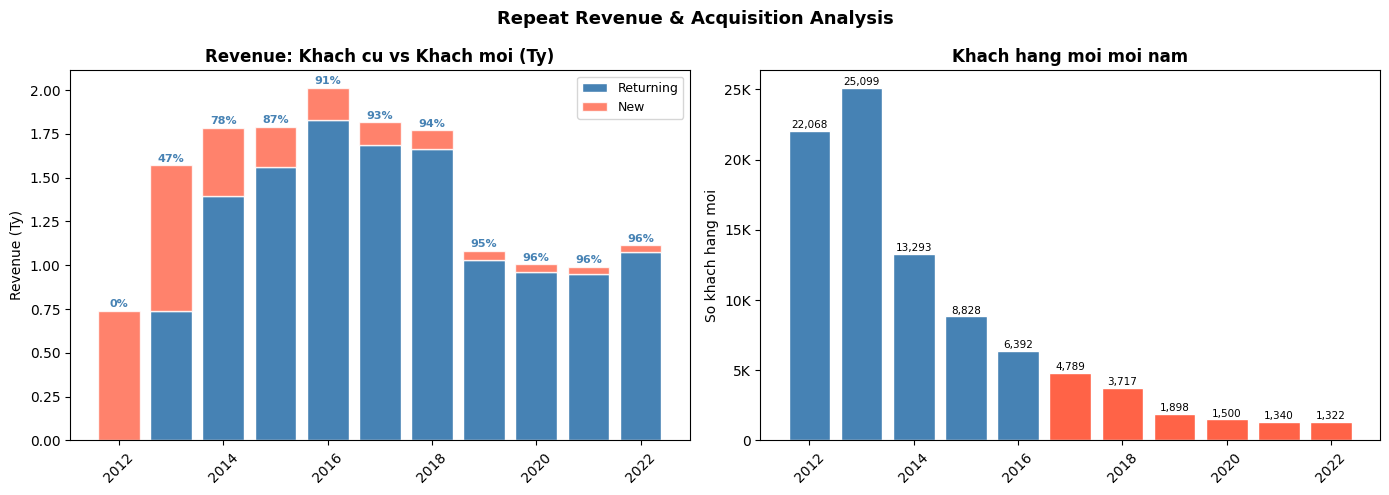

=== REPEAT REVENUE INSIGHTS ===
      returning_rev      new_rev         total  return_pct
year                                                      
2012   0.000000e+00  741497748.0  7.414977e+08         0.0
2013   7.371731e+08  832992086.0  1.570165e+09        47.0
2014   1.395842e+09  389501035.0  1.785343e+09        78.0
2015   1.560600e+09  231409716.0  1.792010e+09        87.0
2016   1.831041e+09  181323575.0  2.012364e+09        91.0
2017   1.687870e+09  127677014.0  1.815547e+09        93.0
2018   1.666448e+09  103275187.0  1.769723e+09        94.0
2019   1.031492e+09   50097536.0  1.081590e+09        95.0
2020   9.617059e+08   44402619.0  1.006109e+09        96.0
2021   9.513652e+08   39849017.0  9.912142e+08        96.0
2022   1.073711e+09   41595990.0  1.115307e+09        96.0

2022 returning %: 96.3%
=> 2022: 96.3% revenue tu khach cu - doanh nghiep khong con thu hut duoc khach moi
=> New customers giam tu 25,099 (2013) xuong con 1,322 (2022) - giam 95%
=> DANGER: neu base 

In [ ]:
first_order_yr = orders.groupby('customer_id')['order_date'].min().dt.year.rename('cohort')
base2 = base.merge(first_order_yr, on='customer_id')
base2["is_new"] = (base2["year"] == base2["cohort"]).astype(int)

repeat = base2.groupby(["year","is_new"])["revenue"].sum().unstack().fillna(0)
repeat.columns = ["returning_rev","new_rev"]
repeat["total"]      = repeat.sum(axis=1)
repeat["new_pct"]    = repeat["new_rev"]       / repeat["total"] * 100
repeat["return_pct"] = repeat["returning_rev"] / repeat["total"] * 100

new_cust_yr = (base2[base2["is_new"]==1]
               .groupby("year")["customer_id"].nunique()
               .reset_index()
               .rename(columns={"customer_id":"new_customers"}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Repeat Revenue & Acquisition Analysis", fontsize=13, fontweight="bold")

ax1.bar(repeat.index, repeat["returning_rev"]/1e9, label="Returning", color="steelblue", edgecolor="white")
ax1.bar(repeat.index, repeat["new_rev"]/1e9, bottom=repeat["returning_rev"]/1e9,
        label="New", color="tomato", edgecolor="white", alpha=0.8)
ax1.set_title("Revenue: Khach cu vs Khach moi (Ty)", fontweight="bold")
ax1.set_ylabel("Revenue (Ty)"); ax1.legend(fontsize=9)
ax1.tick_params(axis="x", rotation=45)
for yr_val in repeat.index:
    rp = repeat.loc[yr_val,"return_pct"]
    ax1.text(yr_val, repeat.loc[yr_val,"total"]/1e9 + 0.02,
             f"{rp:.0f}%", ha="center", fontsize=8, color="steelblue", fontweight="bold")

bar_c = ["tomato" if y >= 2017 else "steelblue" for y in new_cust_yr["year"]]
ax2.bar(new_cust_yr["year"], new_cust_yr["new_customers"], color=bar_c, edgecolor="white")
ax2.set_title("Khach hang moi moi nam", fontweight="bold")
ax2.set_ylabel("So khach hang moi")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K" if x>=1000 else str(int(x))))
ax2.tick_params(axis="x", rotation=45)
for _, r in new_cust_yr.iterrows():
    ax2.text(r["year"], r["new_customers"]+200, f"{r['new_customers']:,.0f}", ha="center", fontsize=7.5)

plt.tight_layout()
plt.show()

print("=== REPEAT REVENUE INSIGHTS ===")
print(repeat[["returning_rev","new_rev","total","return_pct"]].round(0).to_string())
print(f"\n2022 returning %: {repeat.loc[2022,'return_pct']:.1f}%")
print("=> 2022: 96.3% revenue tu khach cu - doanh nghiep khong con thu hut duoc khach moi")
print("=> New customers giam tu 25,099 (2013) xuong con 1,322 (2022) - giam 95%")
print("=> DANGER: neu base khach cu co lai them, khong co nguon thay the")
print("signup_date | check | đơn đầu tiên")

## Insights

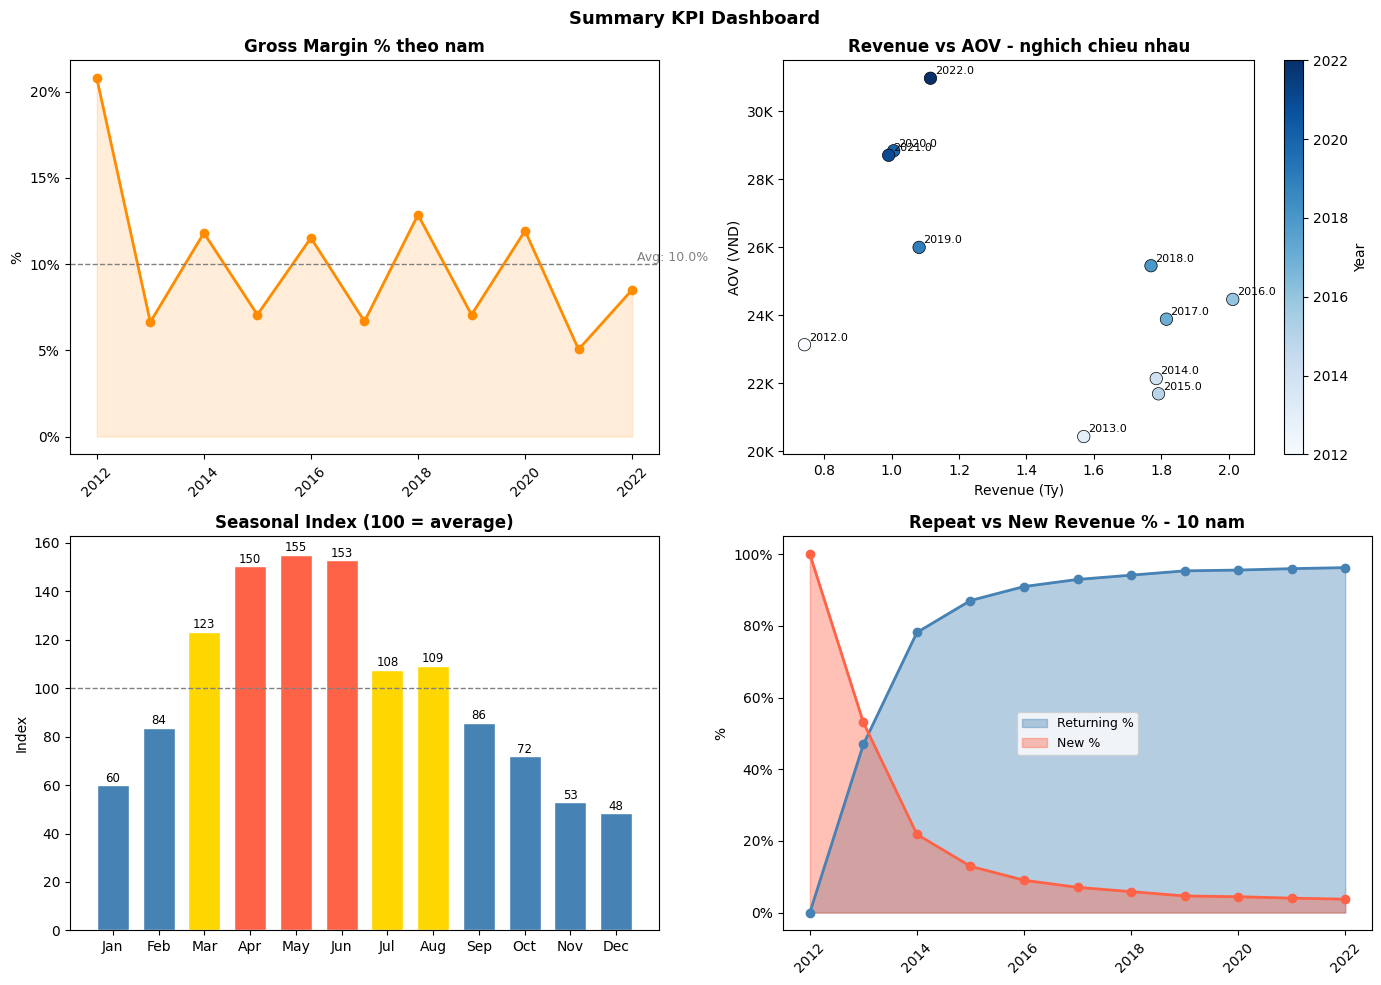

TOP 5 ACTIONABLE INSIGHTS

1. SEASONALITY: Peak thang 4-6 (index 150-155), Low thang 11-12 (index 48-53).
   => Tang inventory va marketing truoc thang 4, khong dau tu vao Q4.
   => Lien quan forecasting: model phai capture spike T4-T6 chinh xac.

2. PORTFOLIO PARADOX: GenZ GM%=15.5% nhung rev_share=2.1%.
   => Dang dau tu sai - category loi nhuan nhat lai duoc it von nhat.
   => Tang GenZ tu 2% len 5% co the cai thien blended GM% dang ke.

3. AOV NGHICH CHIEU REVENUE: Revenue giam nhung AOV tang deu (+52% vs 2013).
   => Khong phai vi san pham kem ma vi khong co khach moi, chi con base premium.
   => Chien luoc dung: giu AOV cao, tap trung tim khach moi chu khong discount.

4. ACQUISITION CRISIS: Khach moi 25,099 (2013) xuong 1,322 (2022), giam 95%.
   => 2022: 96.3% revenue tu tep cu - khong ben vung dai han.
   => Social Media co ARPU tot nhat - nen dau tu kenh nay de rebuild acquisition.

5. WEST REGION PARADOX: ARPU cao nhat (248K) nhung revenue thap nhat.
   => Premium market chu

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Summary KPI Dashboard", fontsize=13, fontweight="bold")

# GM% by year
axes[0,0].plot(yr["year"], yr["gm_pct"], "o-", color="darkorange", linewidth=2, markersize=6)
axes[0,0].fill_between(yr["year"], yr["gm_pct"], alpha=0.15, color="darkorange")
axes[0,0].axhline(y=yr["gm_pct"].mean(), color="gray", linestyle="--", linewidth=1)
axes[0,0].set_title("Gross Margin % theo nam", fontweight="bold")
axes[0,0].set_ylabel("%")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[0,0].text(2022.1, yr["gm_pct"].mean() + 0.2, f"Avg: {yr['gm_pct'].mean():.1f}%", fontsize=9, color="gray")
axes[0,0].tick_params(axis="x", rotation=45)

# AOV vs Revenue scatter
sc = axes[0,1].scatter(yr["revenue"]/1e9, yr["aov"], s=80, c=yr["year"],
                        cmap="Blues", edgecolors="black", linewidth=0.5)
for _, r in yr.iterrows():
    axes[0,1].annotate(str(r["year"]), (r["revenue"]/1e9, r["aov"]),
                        xytext=(3, 3), textcoords="offset points", fontsize=8)
plt.colorbar(sc, ax=axes[0,1], label="Year")
axes[0,1].set_xlabel("Revenue (Ty)"); axes[0,1].set_ylabel("AOV (VND)")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[0,1].set_title("Revenue vs AOV - nghich chieu nhau", fontweight="bold")

# Seasonality
colors_s = ["tomato" if v > 130 else ("gold" if v > 90 else "steelblue")
            for v in monthly["seasonal_index"]]
bars_s = axes[1,0].bar(months_lbl, monthly["seasonal_index"], color=colors_s, edgecolor="white", width=0.7)
axes[1,0].axhline(y=100, color="gray", linestyle="--", linewidth=1)
axes[1,0].set_title("Seasonal Index (100 = average)", fontweight="bold")
axes[1,0].set_ylabel("Index")
for bar, val in zip(bars_s, monthly["seasonal_index"]):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, val+1.5, f"{val:.0f}", ha="center", fontsize=8.5)

# Repeat revenue trend
axes[1,1].fill_between(repeat.index, repeat["return_pct"], alpha=0.4, color="steelblue", label="Returning %")
axes[1,1].fill_between(repeat.index, repeat["new_pct"], alpha=0.4, color="tomato", label="New %")
axes[1,1].plot(repeat.index, repeat["return_pct"], "o-", color="steelblue", linewidth=2)
axes[1,1].plot(repeat.index, repeat["new_pct"], "o-", color="tomato", linewidth=2)
axes[1,1].set_title("Repeat vs New Revenue % - 10 nam", fontweight="bold")
axes[1,1].set_ylabel("%"); axes[1,1].legend(fontsize=9)
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("=" * 65)
print("TOP 5 ACTIONABLE INSIGHTS")
print("=" * 65)
print("""
1. SEASONALITY: Peak thang 4-6 (index 150-155), Low thang 11-12 (index 48-53).
   => Tang inventory va marketing truoc thang 4, khong dau tu vao Q4.
   => Lien quan forecasting: model phai capture spike T4-T6 chinh xac.

2. PORTFOLIO PARADOX: GenZ GM%=15.5% nhung rev_share=2.1%.
   => Dang dau tu sai - category loi nhuan nhat lai duoc it von nhat.
   => Tang GenZ tu 2% len 5% co the cai thien blended GM% dang ke.

3. AOV NGHICH CHIEU REVENUE: Revenue giam nhung AOV tang deu (+52% vs 2013).
   => Khong phai vi san pham kem ma vi khong co khach moi, chi con base premium.
   => Chien luoc dung: giu AOV cao, tap trung tim khach moi chu khong discount.

4. ACQUISITION CRISIS: Khach moi 25,099 (2013) xuong 1,322 (2022), giam 95%.
   => 2022: 96.3% revenue tu tep cu - khong ben vung dai han.
   => Social Media co ARPU tot nhat - nen dau tu kenh nay de rebuild acquisition.

5. WEST REGION PARADOX: ARPU cao nhat (248K) nhung revenue thap nhat.
   => Premium market chua duoc khai thac. Tang coverage tai West = win lon.
""")

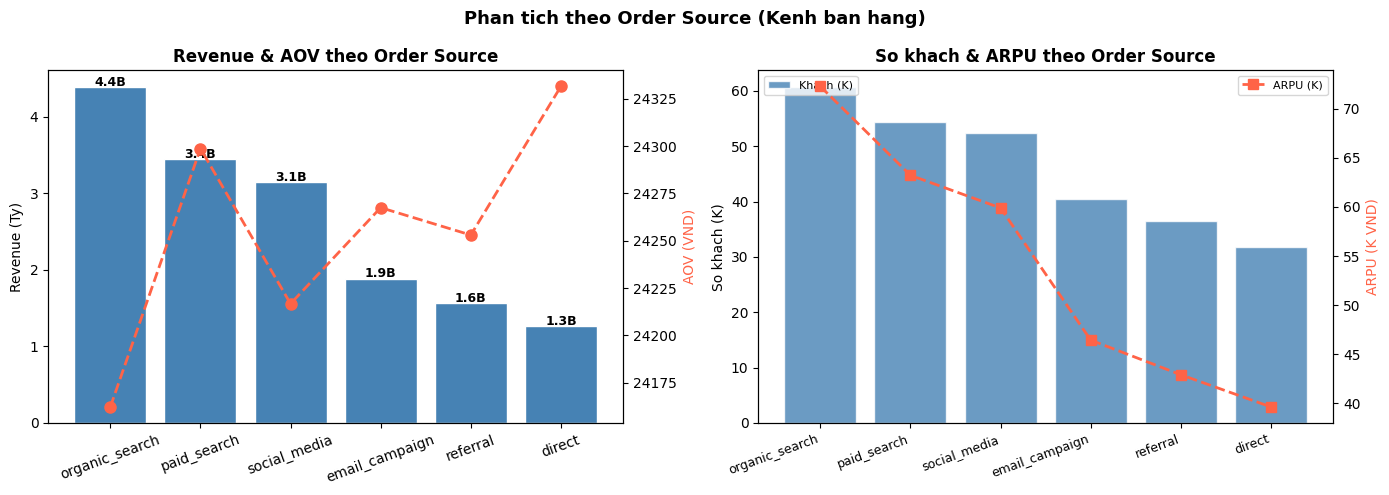

=== ORDER SOURCE INSIGHTS ===
  order_source      revenue  rev_share          aov         arpu  n_cust   gm_pct
organic_search 4.385325e+09  27.966083 24162.235222 72255.402385   60692 9.689418
   paid_search 3.441964e+09  21.950087 24298.735058 63209.821652   54453 9.644058
  social_media 3.141153e+09  20.031756 24216.740963 59887.389569   52451 9.703981
email_campaign 1.882479e+09  12.004942 24267.509937 46446.565034   40530 9.790966
      referral 1.565897e+09   9.986036 24253.036692 42924.816721   36480 9.514111
        direct 1.264050e+09   8.061096 24331.579764 39650.247815   31880 9.687132


In [ ]:
# %% ORDER SOURCE — Kenh ban hang
src = agg_kpi(base, "order_source").sort_values("revenue", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phan tich theo Order Source (Kenh ban hang)", fontsize=13, fontweight="bold")

bars = ax1.bar(src["order_source"], src["revenue"]/1e9,
               color="steelblue", edgecolor="white")
ax1b = ax1.twinx()
ax1b.plot(range(len(src)), src["aov"], "o--",
          color="tomato", linewidth=2, markersize=8, label="AOV")
ax1b.set_ylabel("AOV (VND)", color="tomato")
ax1.set_title("Revenue & AOV theo Order Source", fontweight="bold")
ax1.set_ylabel("Revenue (Ty)")
ax1.tick_params(axis="x", rotation=20)
for bar, v in zip(bars, src["revenue"]/1e9):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.02,
             f"{v:.1f}B", ha="center", fontsize=9, fontweight="bold")

axes2_x = range(len(src))
ax2.bar(axes2_x, src["n_cust"]/1000, color="steelblue",
        edgecolor="white", label="Khach (K)", alpha=0.8)
ax2b = ax2.twinx()
ax2b.plot(axes2_x, src["arpu"]/1000, "s--",
          color="tomato", linewidth=2, markersize=7, label="ARPU (K)")
ax2b.set_ylabel("ARPU (K VND)", color="tomato")
ax2.set_xticks(axes2_x)
ax2.set_xticklabels(src["order_source"], rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("So khach (K)")
ax2.set_title("So khach & ARPU theo Order Source", fontweight="bold")
ax2.legend(loc="upper left", fontsize=8)
ax2b.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("=== ORDER SOURCE INSIGHTS ===")
print(src[["order_source","revenue","rev_share","aov","arpu","n_cust","gm_pct"]].to_string(index=False))

/tmp/ipykernel_16/2079169570.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc="upper left", fontsize=8)


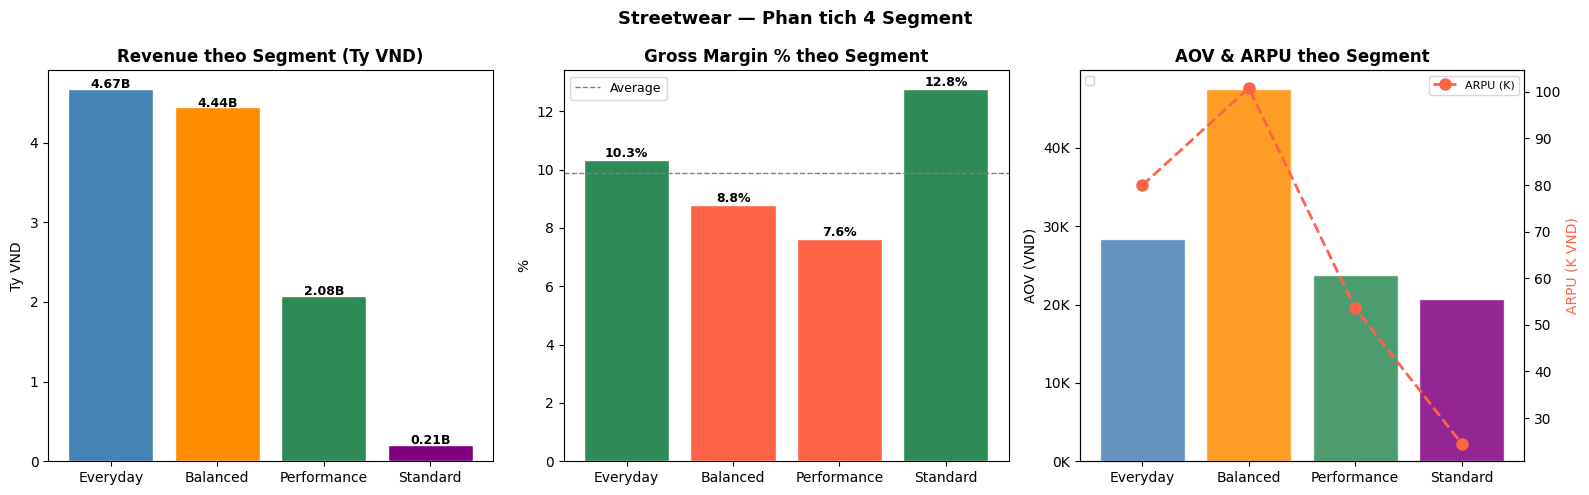

=== STREETWEAR SEGMENT TABLE ===
    segment      revenue  rev_share  gm_pct     aov     arpu
   Everyday 4674822134.3       32.8    10.3 28374.4  79938.8
   Balanced 4443823385.8       31.2     8.8 47524.5 100805.8
Performance 2077298429.9       14.6     7.6 23717.0  53571.8
   Standard  206592439.6        1.5    12.8 20767.2  24530.1

=== TAT CA CATEGORY × SEGMENT ===
  category     segment      revenue  rev_share  gm_pct     aov
    Casual  Activewear   28618045.2        0.2    18.6 29966.5
    Casual All-weather  370702173.7        2.6     6.9 18106.9
      GenZ      Trendy  299248635.0        2.1    15.4  8878.7
   Outdoor  Activewear 1722119196.5       12.1    12.7 11160.8
   Outdoor     Premium  410631188.1        2.9     5.9 14649.2
Streetwear    Balanced 4443823385.8       31.2     8.8 47524.5
Streetwear    Everyday 4674822134.3       32.8    10.3 28374.4
Streetwear Performance 2077298429.9       14.6     7.6 23717.0
Streetwear    Standard  206592439.6        1.5    12.8 20767

In [ ]:
# %% SEGMENT ANALYSIS — Phan tich segment ben trong tung category
base_seg = (oi
    .merge(orders[["order_id","order_date","customer_id","order_status"]], on="order_id")
    .merge(products[["product_id","category","segment","cogs"]], on="product_id", how="left")
)
base_seg = base_seg[base_seg["order_status"] != "cancelled"]
base_seg["year"]    = base_seg["order_date"].dt.year
base_seg["revenue"] = base_seg["quantity"]*base_seg["unit_price"] - base_seg["discount_amount"]
base_seg["gm"]      = base_seg["revenue"] - base_seg["quantity"]*base_seg["cogs"]

seg = base_seg.groupby(["category","segment"]).agg(
    revenue  = ("revenue",  "sum"),
    gm       = ("gm",       "sum"),
    n_orders = ("order_id", "nunique"),
    n_cust   = ("customer_id","nunique")
).reset_index()
seg["gm_pct"]    = seg["gm"]      / seg["revenue"] * 100
seg["aov"]       = seg["revenue"] / seg["n_orders"]
seg["arpu"]      = seg["revenue"] / seg["n_cust"]
seg["rev_share"] = seg["revenue"] / seg["revenue"].sum() * 100

# Chi lay Streetwear
sw = seg[seg["category"]=="Streetwear"].sort_values("revenue", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Streetwear — Phan tich 4 Segment", fontsize=13, fontweight="bold")

colors_seg = ["steelblue","darkorange","seagreen","purple"]
axes[0].bar(sw["segment"], sw["revenue"]/1e9,
            color=colors_seg, edgecolor="white")
axes[0].set_title("Revenue theo Segment (Ty VND)", fontweight="bold")
axes[0].set_ylabel("Ty VND")
for _, r in sw.iterrows():
    axes[0].text(r["segment"], r["revenue"]/1e9 + 0.01,
                 f"{r['revenue']/1e9:.2f}B", ha="center", fontsize=9, fontweight="bold")

axes[1].bar(sw["segment"], sw["gm_pct"],
            color=["tomato" if v < 10 else "seagreen" for v in sw["gm_pct"]],
            edgecolor="white")
axes[1].axhline(sw["gm_pct"].mean(), color="gray", linestyle="--", linewidth=1, label="Average")
axes[1].set_title("Gross Margin % theo Segment", fontweight="bold")
axes[1].set_ylabel("%")
axes[1].legend(fontsize=9)
for _, r in sw.iterrows():
    axes[1].text(r["segment"], r["gm_pct"] + 0.1,
                 f"{r['gm_pct']:.1f}%", ha="center", fontsize=9, fontweight="bold")

axes[2].bar(sw["segment"], sw["aov"],
            color=colors_seg, edgecolor="white", alpha=0.85)
ax2t = axes[2].twinx()
ax2t.plot(range(len(sw)), sw["arpu"]/1000, "o--",
          color="tomato", linewidth=2, markersize=8, label="ARPU (K)")
ax2t.set_ylabel("ARPU (K VND)", color="tomato")
axes[2].set_title("AOV & ARPU theo Segment", fontweight="bold")
axes[2].set_ylabel("AOV (VND)")
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[2].legend(loc="upper left", fontsize=8)
ax2t.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("=== STREETWEAR SEGMENT TABLE ===")
print(sw[["segment","revenue","rev_share","gm_pct","aov","arpu"]].round(1).to_string(index=False))

# So sanh tat ca category × segment
print("\n=== TAT CA CATEGORY × SEGMENT ===")
print(seg[["category","segment","revenue","rev_share","gm_pct","aov"]].round(1).to_string(index=False))

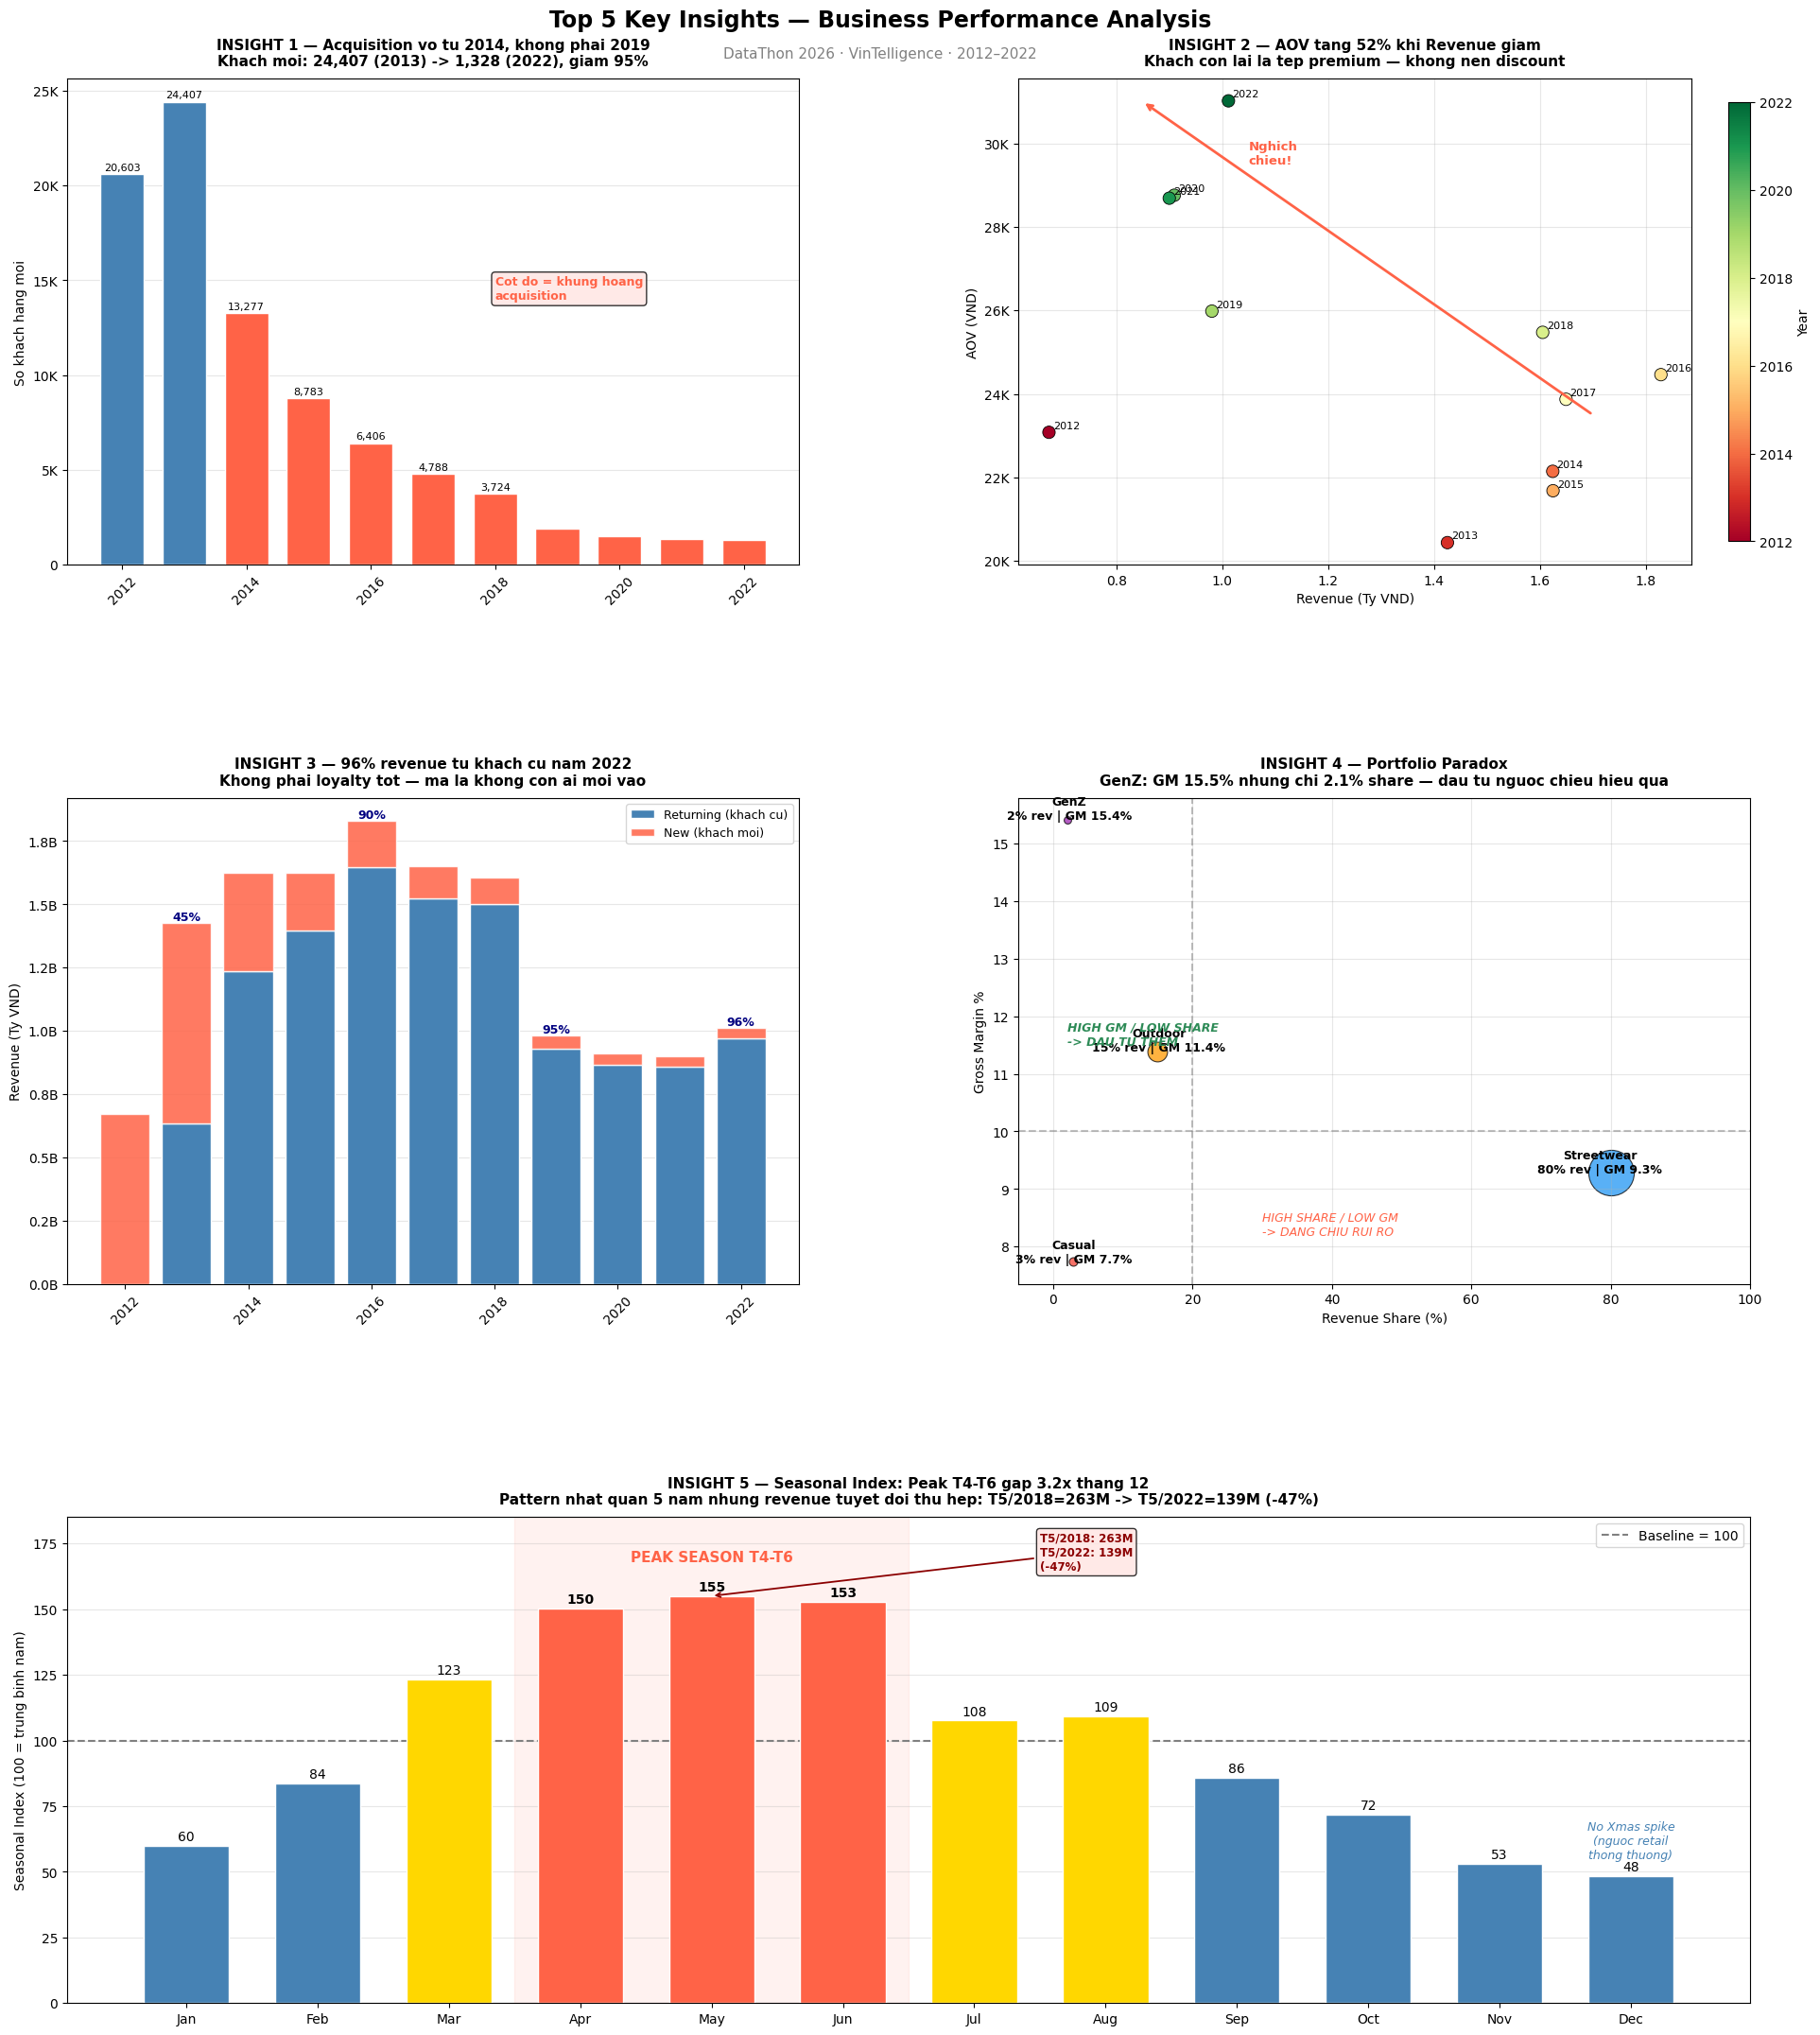

Chart saved


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

oi["revenue"] = oi["quantity"]*oi["unit_price"] - oi["discount_amount"]
base = (oi
    .merge(orders[["order_id","order_date","customer_id","zip","order_status"]], on="order_id")
    .merge(geography[["zip","region"]], on="zip", how="left")
    .merge(customers[["customer_id"]], on="customer_id", how="left")
    .merge(products[["product_id","category","segment","cogs"]], on="product_id", how="left")
)
base = base[base["order_status"] != "cancelled"]
base["year"]  = base["order_date"].dt.year
base["month"] = base["order_date"].dt.month
base["gm"]    = base["revenue"] - base["quantity"]*base["cogs"]

first_ord = orders[orders["order_status"]!="cancelled"].groupby("customer_id")["order_date"].min()
base["cohort"] = base["customer_id"].map(first_ord.dt.year)
base2 = base.copy()
base2["is_new"] = (base2["year"]==base2["cohort"]).astype(int)

YEARS = list(range(2012, 2023))
new_cust = base[base["year"]==base["cohort"]].groupby("year")["customer_id"].nunique()
rev_yr   = base.groupby("year")["revenue"].sum()/1e9
aov_yr   = (base.groupby(["year","order_id"])["revenue"].sum()
            .reset_index().groupby("year")["revenue"].mean())
repeat   = base2.groupby(["year","is_new"])["revenue"].sum().unstack().fillna(0)
repeat.columns = ["returning","new"]
repeat["total"]   = repeat.sum(axis=1)
repeat["ret_pct"] = repeat["returning"]/repeat["total"]*100

cat = base.groupby("category").agg(rev=("revenue","sum"), gm=("gm","sum"),
    n_ord=("order_id","nunique")).reset_index()
cat["gm_pct"]    = cat["gm"]/cat["rev"]*100
cat["rev_share"] = cat["rev"]/cat["rev"].sum()*100
cat = cat.sort_values("rev", ascending=False)

sales["month"] = sales["Date"].dt.month
sales["year"]  = sales["Date"].dt.year
monthly = sales[sales["year"].between(2018,2022)].groupby("month")["Revenue"].mean()
seasonal_idx = (monthly/monthly.mean()*100).round(1)

months_lbl = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("white")
fig.text(0.5, 0.99, "Top 5 Key Insights — Business Performance Analysis",
         ha="center", fontsize=17, fontweight="bold")
fig.text(0.5, 0.975, "DataThon 2026 · VinTelligence · 2012–2022",
         ha="center", fontsize=11, color="gray")

gs = gridspec.GridSpec(3, 2, figure=fig, top=0.965, bottom=0.04,
                       left=0.07, right=0.96, hspace=0.48, wspace=0.3)

# CHART 1: Acquisition collapse
ax1 = fig.add_subplot(gs[0, 0])
nc = [new_cust.get(y,0) for y in YEARS]
bc = ["tomato" if y>=2014 else "steelblue" for y in YEARS]
ax1.bar(YEARS, nc, color=bc, edgecolor="white", width=0.7, zorder=3)
ax1.set_title("INSIGHT 1 — Acquisition vo tu 2014, khong phai 2019\n"
              "Khach moi: 24,407 (2013) -> 1,328 (2022), giam 95%",
              fontweight="bold", fontsize=11, pad=10)
ax1.set_ylabel("So khach hang moi")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K" if x>=1000 else str(int(x))))
ax1.tick_params(axis="x", rotation=45); ax1.grid(axis="y", alpha=0.3)
for bar, v in zip(ax1.patches, nc):
    if v > 2000:
        ax1.text(bar.get_x()+bar.get_width()/2, v+200, f"{v:,.0f}", ha="center", fontsize=8)
ax1.text(2018, 14000, "Cot do = khung hoang\nacquisition", color="tomato",
         fontsize=9, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="mistyrose", alpha=0.8))

# CHART 2: AOV vs Revenue
ax2 = fig.add_subplot(gs[0, 1])
rv = [rev_yr.get(y,0) for y in YEARS]
av = [aov_yr.get(y,0) for y in YEARS]
sc = ax2.scatter(rv, av, c=YEARS, cmap="RdYlGn", s=90, edgecolors="black", linewidth=0.6, zorder=3)
plt.colorbar(sc, ax=ax2, label="Year", fraction=0.03)
for i, y in enumerate(YEARS):
    ax2.annotate(str(y), (rv[i], av[i]), xytext=(3,3), textcoords="offset points", fontsize=8)
ax2.set_xlabel("Revenue (Ty VND)"); ax2.set_ylabel("AOV (VND)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
ax2.set_title("INSIGHT 2 — AOV tang 52% khi Revenue giam\nKhach con lai la tep premium — khong nen discount",
              fontweight="bold", fontsize=11, pad=10)
ax2.grid(alpha=0.3)
ax2.annotate("", xy=(0.85, 31000), xytext=(1.7, 23500),
             arrowprops=dict(arrowstyle="->", color="tomato", lw=2))
ax2.text(1.05, 29500, "Nghich\nchieu!", color="tomato", fontsize=9.5, fontweight="bold")

# CHART 3: 96% returning
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(repeat.index, repeat["returning"]/1e9, label="Returning (khach cu)", color="steelblue", edgecolor="white", zorder=3)
ax3.bar(repeat.index, repeat["new"]/1e9, bottom=repeat["returning"]/1e9,
        label="New (khach moi)", color="tomato", edgecolor="white", alpha=0.85, zorder=3)
for yr in [2013, 2016, 2019, 2022]:
    if yr in repeat.index:
        rp  = repeat.loc[yr,"ret_pct"]
        tot = repeat.loc[yr,"total"]/1e9
        ax3.text(yr, tot+0.01, f"{rp:.0f}%", ha="center", fontsize=9, color="navy", fontweight="bold")
ax3.set_title("INSIGHT 3 — 96% revenue tu khach cu nam 2022\nKhong phai loyalty tot — ma la khong con ai moi vao",
              fontweight="bold", fontsize=11, pad=10)
ax3.set_ylabel("Revenue (Ty VND)"); ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.1f}B"))
ax3.tick_params(axis="x", rotation=45); ax3.grid(axis="y", alpha=0.3)

# CHART 4: Portfolio Matrix
ax4 = fig.add_subplot(gs[1, 1])
colors_cat = {"Streetwear":"#2196f3","Outdoor":"#ff9800","Casual":"#f44336","GenZ":"#9c27b0"}
for _, r in cat.iterrows():
    c = colors_cat.get(r["category"],"gray")
    ax4.scatter(r["rev_share"], r["gm_pct"], s=r["rev_share"]*15,
                color=c, alpha=0.75, edgecolors="black", linewidth=0.8)
    ox = {"Streetwear":-9,"Outdoor":1,"Casual":0.8,"GenZ":1}
    oy = {"Streetwear":0.4,"Outdoor":0.3,"Casual":-0.8,"GenZ":0.4}
    ax4.annotate(f"{r['category']}\n{r['rev_share']:.0f}% rev | GM {r['gm_pct']:.1f}%",
                 (r["rev_share"], r["gm_pct"]),
                 xytext=(ox.get(r["category"],1), oy.get(r["category"],0)),
                 textcoords="offset points", fontsize=9, ha="center", fontweight="bold")
ax4.axvline(x=20, color="gray", linestyle="--", alpha=0.5)
ax4.axhline(y=10, color="gray", linestyle="--", alpha=0.5)
ax4.text(2, 11.5, "HIGH GM / LOW SHARE\n-> DAU TU THEM", fontsize=9, color="seagreen", style="italic", fontweight="bold")
ax4.text(30, 8.2, "HIGH SHARE / LOW GM\n-> DANG CHIU RUI RO", fontsize=9, color="tomato", style="italic")
ax4.set_xlabel("Revenue Share (%)"); ax4.set_ylabel("Gross Margin %")
ax4.set_xlim(-5, 100); ax4.grid(alpha=0.3)
ax4.set_title("INSIGHT 4 — Portfolio Paradox\nGenZ: GM 15.5% nhung chi 2.1% share — dau tu nguoc chieu hieu qua",
              fontweight="bold", fontsize=11, pad=10)

# CHART 5: Seasonality
ax5 = fig.add_subplot(gs[2, :])
s_vals  = [seasonal_idx.get(m,100) for m in range(1,13)]
colors5 = ["tomato" if v>130 else ("gold" if v>90 else "steelblue") for v in s_vals]
bars5   = ax5.bar(months_lbl, s_vals, color=colors5, edgecolor="white", width=0.65, zorder=3)
ax5.axhline(y=100, color="gray", linestyle="--", linewidth=1.5, label="Baseline = 100")
ax5.axvspan(2.5, 5.5, alpha=0.08, color="tomato", zorder=1)
ax5.set_title("INSIGHT 5 — Seasonal Index: Peak T4-T6 gap 3.2x thang 12\n"
              "Pattern nhat quan 5 nam nhung revenue tuyet doi thu hep: T5/2018=263M -> T5/2022=139M (-47%)",
              fontweight="bold", fontsize=11, pad=10)
ax5.set_ylabel("Seasonal Index (100 = trung binh nam)")
ax5.legend(fontsize=10); ax5.set_ylim(0, 185); ax5.grid(axis="y", alpha=0.3)
for bar, val in zip(bars5, s_vals):
    ax5.text(bar.get_x()+bar.get_width()/2, val+2, f"{val:.0f}",
             ha="center", fontsize=10, fontweight="bold" if val>130 else "normal")
ax5.text(4, 168, "PEAK SEASON T4-T6", ha="center", color="tomato", fontsize=11, fontweight="bold")
ax5.text(11, 55, "No Xmas spike\n(nguoc retail\nthong thuong)", ha="center", color="steelblue", fontsize=9, style="italic")
ax5.annotate("T5/2018: 263M\nT5/2022: 139M\n(-47%)", xy=(4,155), xytext=(6.5,165),
             fontsize=8.5, color="darkred", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="darkred", lw=1.3),
             bbox=dict(boxstyle="round,pad=0.3", facecolor="mistyrose", alpha=0.8))

plt.tight_layout()
plt.show()
print("Chart saved")